In [ ]:
# LOAD VOLTAGE SAMPLES FROM FILES

import os
import random
import pandas as pd
import numpy as np

def get_car_name_from_datapath(input_string):
    start_index = 0
    count = 0
    while count<4:
        index = input_string.find('\\', start_index)
        if index == -1:
            break
        count+=1
        start_index = index + 1  # Move past the found substring

    last_hash_index = index = input_string.find('\\', start_index + 1) 
    name = ""
    if last_hash_index != -1:  # Check if '#' was found
        name = input_string[start_index:last_hash_index]
    return name

def get_car_name(input_string):
    last_hash_index = input_string.rfind('\\') 
    last_index = len(input_string) 
    name = ""
    if last_hash_index != -1:  # Check if '#' was found
        name = input_string[last_hash_index + 1:last_index]
    return name

def get_id_from_filename(input_string):
    last_hash_index = input_string.rfind('\\') #\\') 
    last_under_index = input_string.rfind('_') 
    id = -1
    if last_hash_index != -1:  # Check if '#' was found
        id = input_string[last_hash_index + 1:last_under_index]
    return id

def get_leaf_directories(root_path):
    leaf_dirs = []
    for dirpath, dirnames, filenames in os.walk(root_path):
        if not dirnames:  # If dirnames is empty, it's a leaf directory
            leaf_dirs.append(os.path.abspath(dirpath))
    return leaf_dirs

def read_bits(file_path):
    try:
        data = pd.read_csv(
        file_path,
        skiprows=range(6),
        names=range(3),
        delimiter=",",
        nrows= 1600, # set to 2400 for JOHN DEERE
        on_bad_lines='skip'  
        )
        data_list = data.values.tolist()
        third_column = [row[1] - row[2] for row in data_list]
    except pd.errors.ParserError as e:
        print(f"Error reading file {filename}: {e}")
    return third_column


def get_random_subset_strict(arr, max_elements):
    arr_np = np.array(arr) 
    random_indices = random.sample(range(len(arr_np)), min(max_elements, len(arr_np)))
    return arr_np[random_indices]

def get_random_subset(arr, max_elements):
    arr_np = np.array(arr) 
    random_indices = random.sample(range(len(arr_np)), min(max_elements, len(arr_np)))
    while len(random_indices) < max_elements:
        random_indices.append(random.randint(0,len(arr_np)-1))
    return arr_np[random_indices]

data_path = "D:\\DATASETS\\CAN_DATA\\ECUPrint-Clean\\CIVIC"  # ADD YOUR PATH HERE

all_frames = []  

print(data_path)
get_leaf_directories(data_path)

leaf_dirs = get_leaf_directories(data_path)
alldirs = []
id_list = []

all_bits_from_all_ids = []  
all_bits_to_plot = []  
all_bits_flat = []


all_intra_cor_mat = []
all_intra_dtw_mat = []

no_bits = 500
no_samples = 50
scaling = 0 # set to 1 for min-max scaling in the normal range for CAN voltages

print("\nLeaf Directories:")
for leaf_dir in leaf_dirs:
    all_bits = [] 
    id_list.append(get_car_name_from_datapath(leaf_dir) + '_' + get_id_from_filename(leaf_dir))
    print("ID: ", id_list[len(id_list)-1])
    #read all bits from each file in the dir
    for filename in os.listdir(leaf_dir):
            file_path = os.path.join(leaf_dir, filename)
            #print(file_path)
            new_bits = read_bits(file_path)
            if scaling == 0:
                all_bits.append(new_bits) 
            else: 
                mi = min(new_bits)
                ma = max(new_bits)
                result = [2*(item - mi)/(ma-mi) for item in new_bits]
                all_bits.append(result)
    print(leaf_dir)
    alldirs.append(leaf_dir)
    print("No. bits: ", len(all_bits))
    all_bits_to_plot.append(all_bits)
    all_bits = get_random_subset(all_bits, no_bits) # specify here the max number of bits
    print("Used bits: ", len(all_bits))
    all_bits_from_all_ids.append(all_bits)
    all_bits_flat.extend(all_bits)



D:\DATASETS\CAN_DATA\ECUPrint-Clean\CIVIC

Leaf Directories:
ID:  CIVIC_039
D:\DATASETS\CAN_DATA\ECUPrint-Clean\CIVIC\ECU1\039_aligned
No. bits:  220
Used bits:  500
ID:  CIVIC_305
D:\DATASETS\CAN_DATA\ECUPrint-Clean\CIVIC\ECU1\305_aligned
No. bits:  70
Used bits:  500
ID:  CIVIC_401
D:\DATASETS\CAN_DATA\ECUPrint-Clean\CIVIC\ECU1\401_aligned
No. bits:  43
Used bits:  500
ID:  CIVIC_1A6
D:\DATASETS\CAN_DATA\ECUPrint-Clean\CIVIC\ECU2\1A6_aligned
No. bits:  447
Used bits:  500
ID:  CIVIC_21E
D:\DATASETS\CAN_DATA\ECUPrint-Clean\CIVIC\ECU2\21E_aligned
No. bits:  342
Used bits:  500
ID:  CIVIC_221
D:\DATASETS\CAN_DATA\ECUPrint-Clean\CIVIC\ECU2\221_aligned
No. bits:  231
Used bits:  500
ID:  CIVIC_294
D:\DATASETS\CAN_DATA\ECUPrint-Clean\CIVIC\ECU2\294_aligned
No. bits:  547
Used bits:  500
ID:  CIVIC_295
D:\DATASETS\CAN_DATA\ECUPrint-Clean\CIVIC\ECU2\295_aligned
No. bits:  96
Used bits:  500
ID:  CIVIC_309
D:\DATASETS\CAN_DATA\ECUPrint-Clean\CIVIC\ECU2\309_aligned
No. bits:  91
Used bits:  50

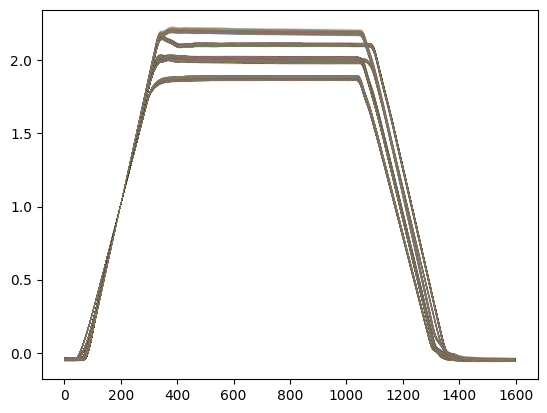

43


In [27]:
# PLOT LOADED SAMPLES/BITS FOR A SIMPLE CHECK

import matplotlib.pyplot as plt

for i in range(len(all_bits_from_all_ids)):
    for j in range(len(all_bits_from_all_ids[i])):
        plt.plot(all_bits_from_all_ids[i][j], alpha=0.3, lw=0.1)
plt.show()
print(len(all_bits_from_all_ids))


In [36]:
# SAMPLE SPLITTING AND OTHER FUNCTIONS FOR CONTRAINT-GUIDED CLUSTERING

import hashlib

def get_random_subset(arr, max_elements):
    arr_np = np.array(arr) #Convert to numpy array.
    random_indices = random.sample(range(len(arr_np)), min(max_elements, len(arr_np)))
    while len(random_indices) < max_elements:
        random_indices.append(random.randint(0,len(arr_np)-1))
    return arr_np[random_indices]

def select_from_all_bits(arr, no_samples):
    samples = []
    for i in range(len(arr)):
        samples.append(get_random_subset(arr[i], no_samples))
    return samples

def get_promoter_censor(arr):
    pc_arr = []
    for i in range(len(arr)):
        promoter=[]
        censor=[]
        split_point = len(arr[i]) // 2
        indexes = list(range(2*split_point))
        random.shuffle(indexes)
        promoter_indexes = indexes[:split_point]
        censor_indexes = indexes[split_point:]
        for j in range(split_point):
            promoter.extend(arr[i][promoter_indexes[j]])
            censor.extend(arr[i][censor_indexes[j]])
        pc_arr.append(promoter)
        pc_arr.append(censor)
    return pc_arr

def promoter_censor_print_clusters(labels, id_list):
    no_labels =  len(np.unique(labels))
    clusters = []
    for i in range(no_labels):
        clusters.append([])
    i=0
    if len(labels) != 2*len(id_list): print("LABELS AND NO. IDS DO NOT MATCH ", len(labels), 2*len(id_list))
    if max(labels) >= no_labels: print("LABELS ARE NOT 0-BASED INDEXED, MAX LABEL/NO LABES: ", max(labels), no_labels)
    while(i<len(labels)):
        #print(i)
        if labels[i]!=labels[i+1]: print("Promoter-Censor Labels Do Not Match for ID: ", id_list[i//2])
        clusters[labels[i]].append(id_list[i//2])
        i = i + 2
    print("No. clusters: ", len(clusters)) 
    cluster_hashes = [] 
    for l in clusters:
        print("Clustered: ", sorted(l))
        hashcode = hashlib.md5(str(tuple(sorted(l))).encode('utf-8')).hexdigest()
        print("Hashcode: ", hashcode)#hash(tuple(sorted(l))))
        if len(l)>0: cluster_hashes.append(hashcode)#hash(tuple(sorted(l))))
    clustering_index = hashlib.md5(str(tuple(sorted(cluster_hashes))).encode('utf-8')).hexdigest() #hash(tuple(sorted(cluster_hashes)))
    print("Clustering hash: ", clustering_index)
    return clustering_index

def get_adjacency_matrix(labels, id_list):

    n = len(id_list)
    a_matrix = np.zeros((n, n))

    no_labels =  len(np.unique(labels))
    clusters = []
    for i in range(no_labels):
        clusters.append([])
    i=0
    while(i<len(labels)):
        clusters[labels[i]].append(id_list[i//2])
        i = i + 2

    for cluster in clusters:
        for i in range(len(cluster)):
            for j in range(i,len(cluster)):
                index_i = id_list.index(cluster[i])
                index_j = id_list.index(cluster[j])
                a_matrix[index_i][index_j] = 1
                a_matrix[index_j][index_i] = 1

    return a_matrix

def get_adjacency_matrix_full(labels, id_list):

    n = 2*len(id_list)
    a_matrix = np.zeros((n, n))

    if n!=len(labels): print("There is a mismatch between the number of labels and ids !!!")

    for i in range(n):
        a_matrix[i][i] = labels[i]
    
    for i in range(n):
        for j in range(i+1,n):
                if a_matrix[i][i] == a_matrix[j][j]:
                    a_matrix[i][j] = 1
                    a_matrix[j][i] = 1

    for i in range(n):
        a_matrix[i][i] = 1

    return a_matrix


new_filtered_bits = select_from_all_bits(all_bits_to_plot, 200) 
    

86
Gamma selected as:  0.01451513462577473
No. clusters:  2
Clustered:  ['CIVIC_039', 'CIVIC_091', 'CIVIC_18E', 'CIVIC_19B', 'CIVIC_1A4', 'CIVIC_1A6', 'CIVIC_1AA', 'CIVIC_1B0', 'CIVIC_1D0', 'CIVIC_1EA', 'CIVIC_21E', 'CIVIC_221', 'CIVIC_255', 'CIVIC_294', 'CIVIC_295', 'CIVIC_305', 'CIVIC_309', 'CIVIC_372', 'CIVIC_374', 'CIVIC_377', 'CIVIC_378', 'CIVIC_386', 'CIVIC_3D9', 'CIVIC_401', 'CIVIC_405', 'CIVIC_406', 'CIVIC_428', 'CIVIC_42D', 'CIVIC_42E']
Hashcode:  6c25feb4384e144d045e44bbfd19115a
Clustered:  ['CIVIC_13C', 'CIVIC_156', 'CIVIC_158', 'CIVIC_17C', 'CIVIC_1DC', 'CIVIC_1ED', 'CIVIC_320', 'CIVIC_324', 'CIVIC_328', 'CIVIC_3D7', 'CIVIC_400', 'CIVIC_40C', 'CIVIC_454', 'CIVIC_465']
Hashcode:  e445e0884976cff3b1d6c25b6108f54e
Clustering hash:  7ab5a941a9ded9a22cb3795c9fd90953
Gamma selected as:  0.014519273116012019
No. clusters:  2
Clustered:  ['CIVIC_039', 'CIVIC_091', 'CIVIC_18E', 'CIVIC_19B', 'CIVIC_1A4', 'CIVIC_1A6', 'CIVIC_1AA', 'CIVIC_1B0', 'CIVIC_1D0', 'CIVIC_1EA', 'CIVIC_21E', 'C

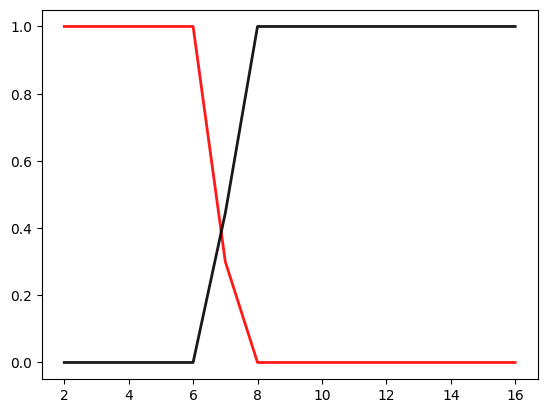

Correctness & Divergence Scores: 
[1.0, 1.0, 1.0, 1.0, 1.0, 0.3, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.4444444444444444, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


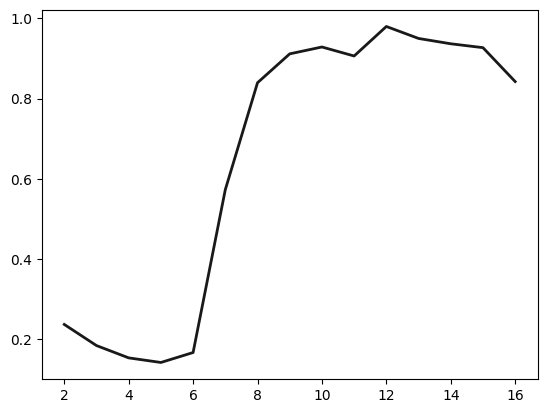

Davies-Bouldin, Optimal number of clusters: 5


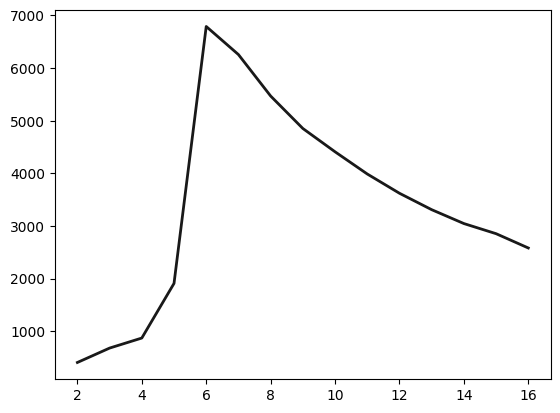

Calinski-Harabasz, optimal number of clusters: 6


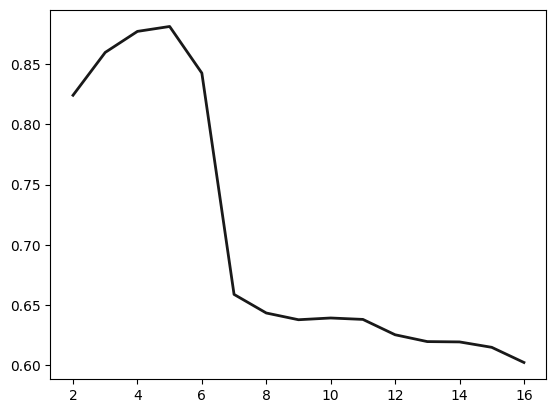

Silhouette, optimal number of clusters: 5


In [37]:
#PROMOTER-CENSOR ON SPECTRAL

import matplotlib.pyplot as plt

import random
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score

X = []
X=get_promoter_censor(new_filtered_bits)
print(len(X))

n = len(id_list)
all_matrix = np.zeros((n, n))
all_matrix_full = np.zeros((2*n, 2*n))
all_matrix_full_list = []

scores_CGC = []
scores_CH_all = []
scores_DB_all = []
scores_SH_all = []
cluster_correctness = []
cluster_divergence = []
indexed_clusters = {}
winner_clusters = []
all_gamma = []

min_clusters = 2
delta_clusters =  15
no_attempts = 10

for k in range(min_clusters, min_clusters + delta_clusters):  
    attempts = 0
    wrong = 0
    right= 0
    labels = []
    cluster_labels = []
    cluster_correct = []
    scores_CH = []
    scores_DB = []
    scores_SH = []
    while attempts<no_attempts:
        new_filtered_bits = select_from_all_bits(all_bits_to_plot, 200) 
        X=get_promoter_censor(new_filtered_bits)
        pca = PCA(16)
        X_reduced = pca.fit_transform(X)  
        distances = pdist(X_reduced, metric='euclidean')
        mean_distance = np.mean(distances)
        gam = 1/(2*(mean_distance))
        all_gamma.append(gam)
        print("Gamma selected as: ", gam)
        random_seed = random.randint(0, 1000)
        spectral = SpectralClustering(n_clusters=k, affinity="rbf",  gamma=gam, random_state=random_seed, n_jobs=-1) 
        labels = spectral.fit_predict(X_reduced)
        if len(np.unique(labels)) != k: print("CLUSTERING ERROR, WANTERD ", k, "CLUSTERS, RECEIVED", len(np.unique(labels)))
        cll = promoter_censor_print_clusters(labels, id_list)
        indexed_clusters[cll] = labels
        cluster_labels.append(cll)
        all_matrix =  all_matrix + get_adjacency_matrix(labels, id_list) 
        all_matrix_full = all_matrix_full + get_adjacency_matrix_full(labels, id_list)
        i = 0
        correct = 1
        while(i<len(labels)):
            if labels[i]!=labels[i+1]: 
                wrong+= 1
                correct = 0
            else: right+= 1
            i=i+2
        cluster_correct.append(correct)
        score = calinski_harabasz_score(X_reduced, labels) 
        scores_CH.append(score)
        score = davies_bouldin_score(X_reduced, labels)
        scores_DB.append(score)
        score = silhouette_score(X_reduced, labels) 
        scores_SH.append(score)
        attempts+=1
    all_matrix_full_list.append(all_matrix_full)
    scores_CH_all.append(np.median(scores_CH))
    scores_DB_all.append(np.median(scores_DB))
    scores_SH_all.append(np.median(scores_SH))
    print("At cluster size: ", k, " Promoter/Censor on Spectral predicted ", len(np.unique(labels)), " clusters. Correct: ", right/(no_attempts * len(labels)/2)*100, " Wrong: ", wrong/(no_attempts * len(labels)/2)*100)
    scores_CGC.append(right/(no_attempts * len(labels)/2)*100)
    cluster_correctness.append(sum(cluster_correct)/no_attempts)
    #promoter_censor_print_clusters(labels, id_list) #PRINT THE CLUSTERS
    print("Unique clusterings: ", len(set(cluster_labels)), "Cluster labels: ", sorted(cluster_labels))
    cluster_divergence.append((len(set(cluster_labels))-1)/(no_attempts-1))
    counts = Counter(cluster_labels)
    most_common_cluster = counts.most_common(1)[0][0]
    print("Most common cluster index:", most_common_cluster, " occurs ", counts.most_common(1)[0][1], " times" )
    winner_clusters.append((most_common_cluster, counts.most_common(1)[0][1]))
    print("That is: ")
    promoter_censor_print_clusters(indexed_clusters[most_common_cluster], id_list)
    

x_values = list(range(min_clusters, len(scores_CGC)+min_clusters))

plt.plot(x_values, cluster_correctness, alpha=0.9, lw = 2, color = "red")
plt.plot(x_values, cluster_divergence, alpha=0.9, lw = 2, color = "black")
plt.show()
print("Correctness & Divergence Scores: ")
print(cluster_correctness)
print(cluster_divergence)

plt.plot(x_values, scores_DB_all, alpha=0.9, lw = 2, color = "black")
plt.show()
optimal_k_DB = np.argmin(scores_DB_all) + min_clusters
print(f"Davies-Bouldin, Optimal number of clusters: {optimal_k_DB}")

plt.plot(x_values, scores_CH_all, alpha=0.9, lw = 2, color = "black")
plt.show()
optimal_k_CH = np.argmax(scores_CH_all) + min_clusters  
print(f"Calinski-Harabasz, optimal number of clusters: {optimal_k_CH}")

plt.plot(x_values, scores_SH_all, alpha=0.9, lw = 2, color = "black")
plt.show()
optimal_k_SH = np.argmax(scores_SH_all) + min_clusters  
print(f"Silhouette, optimal number of clusters: {optimal_k_SH}")



